In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, ConfusionMatrixDisplay

In [48]:
iris= datasets.load_iris()
X, y= iris.data[:, :2], iris.target
X= pd.DataFrame(X, columns= iris.feature_names[:2])
y= pd.DataFrame(y, columns= ['target'])
X.sample(5)

,sepal length (cm),sepal width (cm)
31,5.4,3.4
114,5.8,2.8
105,7.6,3.0
42,4.4,3.2
38,4.4,3.0


# Train Test Split

In [49]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

In [50]:
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [51]:
svc= SVC(kernel='rbf', C= 1.0, gamma='scale', random_state= 42)

# Uses the Radial Basis Function (RBF) kernel.
# Regularization parameter.

# C= 1.0
# Controls the trade-off between:
# Low error on training data
# Smooth decision boundary
# Smaller C → smoother boundary (more regularization)
# Larger C → tries to classify all training points correctly

# scale
# Determines how far the influence of a single data point reaches.
# High gamma → overfitting (tight boundaries)
# Low gamma → underfitting (looser boundaries)

svc.fit(X_train_scaled, y_train)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [52]:
y_pred= svc.predict(X_test_scaled)

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.70      0.78      0.74         9
           2       0.80      0.73      0.76        11

    accuracy                           0.83        30
   macro avg       0.83      0.84      0.83        30
weighted avg       0.84      0.83      0.83        30



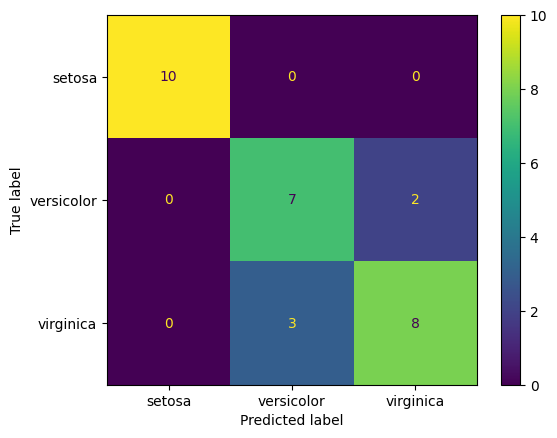

In [53]:
print("Classification Report:", classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,  display_labels=iris.target_names)
plt.show()

# Class 0 → Setosa
# Class 1 → Versicolor
# Class 2 → Virginica


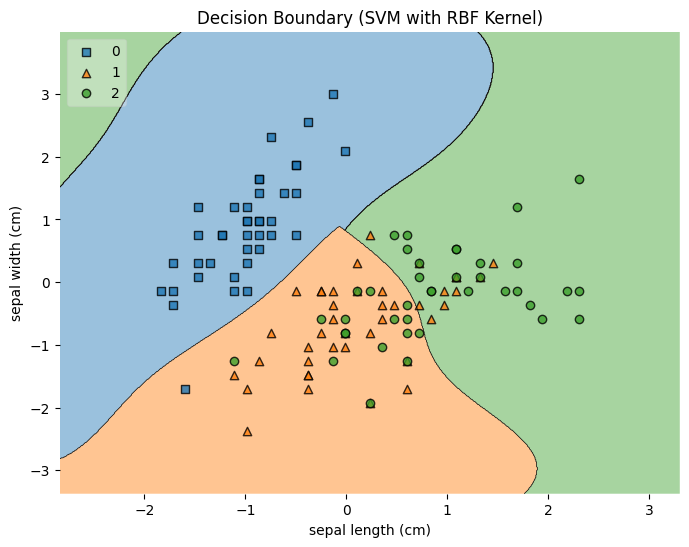

In [61]:
from mlxtend.plotting import plot_decision_regions

# mlxtend requires numpy arrays for X and y
X_train_arr = X_train_scaled
y_train_arr = y_train.values.ravel()   # .ravel() flattens the array from 2D → 1D:

plt.figure(figsize=(8,6))

plot_decision_regions(X_train_arr, y_train_arr, clf=svc, legend=2)

plt.title("Decision Boundary (SVM with RBF Kernel)")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()